In [1]:
using DifferentialEquations
using LightGraphs
using GraphRecipes
using Statistics
using LaTeXStrings
using Plots
using LinearAlgebra
using LsqFit

# 2 Oscillators

In [2]:
function soltn(k,θ,u0,tspan,σ)
    
    function f(du,u,p,t)
        du[1]=(1/2)-(k/2)*sin(u[1]-u[2])
        du[2]=(-1/2)-(k/2)*sin(u[2]-u[1])
    end
    
    function g(du,u,p,t)
        G=(σ/sqrt(2))*[[cos(θ),sin(θ)] [sin(θ),cos(θ)]]
        du.=G
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(2,2))
    sol=solve(prob,EM(),dt=0.04)
    return sol
end

soltn (generic function with 1 method)

In [3]:
u0=[0,0.01]
sol1=soltn(1.1,pi/4, u0,(0.0,50.0),sqrt(2))
p1=plot(sol1,title="Oscillator Phases")
p2=plot([sol1.t[i] for i in 1:length(sol1[1,1:end])],abs.([sol1[1,i] for i in 1:length(sol1[1,1:end])].-[sol1[2,i] for i in 1:length(sol1[1,1:end])]),title="Phase Difference")
plot(p1,p2)


LoadError: InterruptException:

In [4]:
function r2(sol,tspan)
    Δt=tspan[2]-tspan[1]
    leng=length(sol[1,1:end])
    return (1/Δt)*sum(abs2.((1/2)*(exp.(sol[1,1:end].*im)+exp.(sol[2,1:end].*im))).*Δt/(leng-1))
end


r2 (generic function with 1 method)

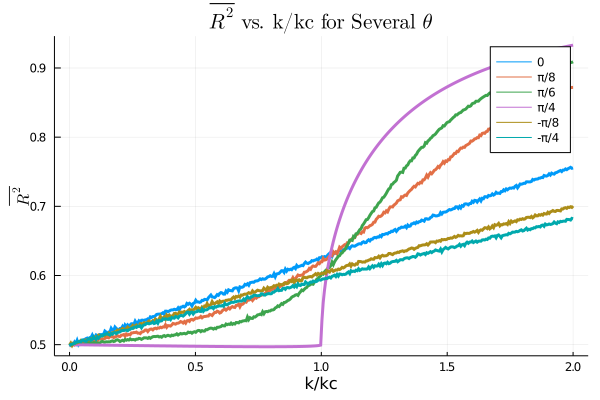

In [6]:
tf=85000.0
u0=[1,0]
a(k)=r2(soltn(k,0,u0,(0.0,tf),sqrt(2)),(0.0,tf))
b(k)=r2(soltn(k,pi/8,u0,(0.0,tf),sqrt(2)),(0.0,tf))
c(k)=r2(soltn(k,pi/6,u0,(0.0,tf),sqrt(2)),(0.0,tf))
d(k)=r2(soltn(k,pi/4,u0,(0.0,tf),sqrt(2)),(0.0,tf))
e(k)=r2(soltn(k,-pi/8,u0,(0.0,tf),sqrt(2)),(0.0,tf))
f(k)=r2(soltn(k,-pi/4,u0,(0.0,tf),sqrt(2)),(0.0,tf))
plot(LinRange(0,2,400),[a,b,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. k/kc for Several θ}",label=["0" "π/8" "π/6" "π/4" "-π/8" "-π/4"],xlabel="k/kc",ylabel=L"\overline{R^2}",width=3)


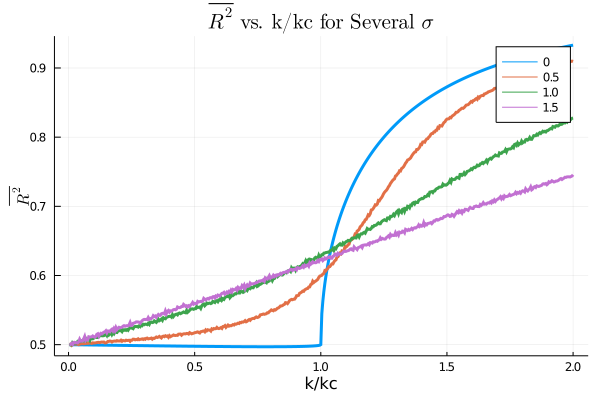

In [9]:
tf=85000.0
e(k)=r2(soltn(k,0,u0,(0.0,tf),0),(0.0,tf))
f(k)=r2(soltn(k,0,u0,(0.0,tf),0.5),(0.0,tf))
g(k)=r2(soltn(k,0,u0,(0.0,tf),1),(0.0,tf))
h(k)=r2(soltn(k,0,u0,(0.0,tf),1.5),(0.0,tf))
plot(LinRange(0,2,400),[e,f,g,h],title= L"\overline{R^2} \textrm{ vs. k/kc for Several σ}",label=["0" "0.5" "1.0" "1.5"],xlabel="k/kc",ylabel=L"\overline{R^2}",width=3)


In [ ]:
#Checking to see if expansion works for small k
tf=100000.0
a(k)=1/2+(1/4)*(0.1^2)*k
b(k)=1/2+(1/4)*(0.15^2)*k
c(k)=1/2+(1/4)*(0.2^2)*k
d(k)=1/2+(1/4)*(0.3^2)*k
e(k)=r2(soltn(k,0,u0,(0.0,tf),0.1),(0.0,tf))
f(k)=r2(soltn(k,0,u0,(0.0,tf),0.15),(0.0,tf))
g(k)=r2(soltn(k,0,u0,(0.0,tf),0.2),(0.0,tf))
h(k)=r2(soltn(k,0,u0,(0.0,tf),0.3),(0.0,tf))
plot(LinRange(0,0.1,300),[a,b,c,d,e,f,g,h],title= L"\overline{R^2} \textrm{ vs. k/kc for Several σ (Small k) with Expansion Fits}",label=["0.1 Fit" "0.15 Fit" "0.2 Fit" "0.3 Fit" "0.1" "0.15" "0.2" "0.3"],xlabel="k/kc",ylabel=L"\overline{R^2}",width=3)


In [ ]:
u0=[1,1]
tf=85000.0
a(σ)=r2(soltn(0.95,0,u0,(0.0,tf),σ),(0.0,tf))
b(σ)=r2(soltn(0.95,pi/8,u0,(0.0,tf),σ),(0.0,tf))
c(σ)=r2(soltn(0.95,pi/6,u0,(0.0,tf),σ),(0.0,tf))
d(σ)=r2(soltn(0.95,pi/4,u0,(0.0,tf),σ),(0.0,tf))
e(σ)=r2(soltn(0.95,-pi/8,u0,(0.0,tf),σ),(0.0,tf))
f(σ)=r2(soltn(0.95,-pi/4,u0,(0.0,tf),σ),(0.0,tf))
plot(LinRange(0,5,400),[a,b,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. σ for Several θ}",label=["0" "π/8" "π/6" "π/4" "-π/8" "-π/4"],xlabel="σ",ylabel=L"\overline{R^2}",width=3)


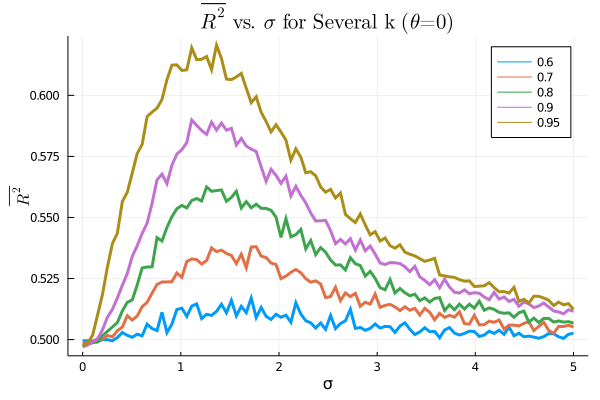

In [56]:
#Discussion of eta optimal
u0=[1,1]
tf=15000
a(σ)=r2(soltn(0.1,0,u0,(0.0,tf),σ),(0.0,tf))
b(σ)=r2(soltn(0.3,0,u0,(0.0,tf),σ),(0.0,tf))
c(σ)=r2(soltn(0.5,0,u0,(0.0,tf),σ),(0.0,tf))
d(σ)=r2(soltn(0.7,0,u0,(0.0,tf),σ),(0.0,tf))
e(σ)=r2(soltn(0.9,0,u0,(0.0,tf),σ),(0.0,tf))
plot(LinRange(0,5,100),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. σ for Several k (θ=0)}",label=["0.6" "0.7" "0.8" "0.9" "0.95"],xlabel="σ",ylabel=L"\overline{R^2}",width=3)


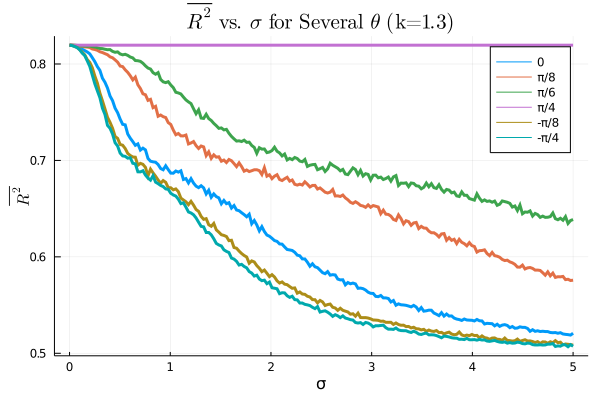

In [11]:
u0=[1,1]
tf=25000.0
a(σ)=r2(soltn(1.3,0,u0,(0.0,tf),σ),(0.0,tf))
b(σ)=r2(soltn(1.3,pi/8,u0,(0.0,tf),σ),(0.0,tf))
c(σ)=r2(soltn(1.3,pi/6,u0,(0.0,tf),σ),(0.0,tf))
d(σ)=r2(soltn(1.3,pi/4,u0,(0.0,tf),σ),(0.0,tf))
e(σ)=r2(soltn(1.3,-pi/8,u0,(0.0,tf),σ),(0.0,tf))
f(σ)=r2(soltn(1.3,-pi/4,u0,(0.0,tf),σ),(0.0,tf))
plot(LinRange(0,5,200),[a,b,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. σ for Several θ (k=1.3)}",label=["0" "π/8" "π/6" "π/4" "-π/8" "-π/4"],xlabel="σ",ylabel=L"\overline{R^2}",width=3)


In [4]:
a(θ,σ,k,tf)=r2(soltn(k,θ,u0,(0.0,tf),σ),(0.0,tf))

a (generic function with 1 method)

# Rayleigh Curve Fit

In [6]:
function fitter2(θ,k,tf)
    m(x, p) = p[1].*(x./(p[2].^2)).*exp.((-(x.^p[3])./(2 .* (p[2].^2)))) .+ p[4];
    p0 = [0.5,2,1.5,0.5]
    tdata=LinRange(0,8,1000)
    ydata=a.(θ,tdata,k,tf)
    fit = curve_fit(m, tdata, ydata, p0)
    pa=fit.param
    return pa
end

fitter2 (generic function with 1 method)

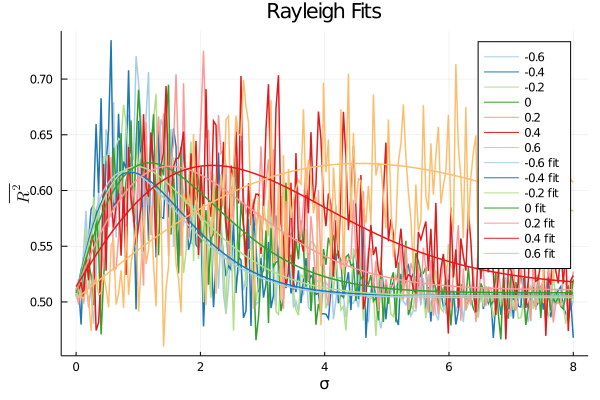

In [62]:
u0=[1,0]
tf=50
t=LinRange(0,8,200)
pa0=fitter2(-0.6,0.95,tf)
z(x)=pa0[1]*(x/(pa0[2].^2))*exp((-(x^pa0[3])/(2 * (pa0[2]^2)))) + pa0[4]
pa1=fitter2(-0.4,0.95,tf)
b(x)=pa1[1]*(x/(pa1[2].^2))*exp((-(x^pa1[3])/(2 * (pa1[2]^2)))) + pa1[4]
pa2=fitter2(-0.2,0.95,tf)
c(x)=pa2[1]*(x/(pa2[2].^2))*exp((-(x^pa2[3])/(2 * (pa2[2]^2)))) + pa2[4]
pa3=fitter2(0,0.95,tf)
d(x)=pa3[1]*(x/(pa3[2].^2))*exp((-(x^pa3[3])/(2 * (pa3[2]^2)))) + pa3[4]
pa4=fitter2(0.2,0.95,tf)
e(x)=pa4[1]*(x/(pa4[2].^2))*exp((-(x^pa4[3])/(2 * (pa4[2]^2)))) + pa4[4]
pa5=fitter2(0.4,0.95,tf)
f(x)=pa5[1]*(x/(pa5[2].^2))*exp((-(x^pa5[3])/(2 * (pa5[2]^2)))) + pa5[4]
pa6=fitter2(0.6,0.95,tf)
g(x)=pa6[1]*(x/(pa6[2].^2))*exp((-(x^pa6[3])/(2 * (pa6[2]^2)))) + pa6[4]
plot(t,[a.(-0.6,t,0.95,tf),a.(-0.4,t,0.95,tf),a.(-0.2,t,0.95,tf),a.(0,t,0.95,tf),a.(0.2,t,0.95,tf),a.(0.4,t,0.95,tf),a.(0.6,t,0.95,tf),z,b,c,d,e,f,g],title= "Rayleigh Fits",label=["-0.6" "-0.4" "-0.2" "0" "0.2" "0.4" "0.6" "-0.6 fit" "-0.4 fit" "-0.2 fit" "0 fit" "0.2 fit" "0.4 fit" "0.6 fit"],palette=palette(:Paired_7),xlabel="σ",ylabel=L"\overline{R^2}",width=1.5)


In [7]:
function maxfind(θ,k,tf)
    pa=fitter2(θ,k,tf)
    f(x)=pa[1]*(x/(pa[2].^2))*exp((-(x^pa[3])/(2 * (pa[2]^2)))) + pa[4]
    return findmax(f.(LinRange(0,12,360)))[2]/30
end

maxfind (generic function with 1 method)

In [8]:
function fitter(k)
    tdata=LinRange(-0.6,0.6,16)
    data=maxfind.(tdata,k,2500)
    m(x, p) = sqrt(2)*p[1]./sqrt.(1 .-sin.(2*x))
    p0 = [0.8]
    fit = curve_fit(m, tdata, data, p0)
    return fit.param[1]
end

fitter (generic function with 1 method)

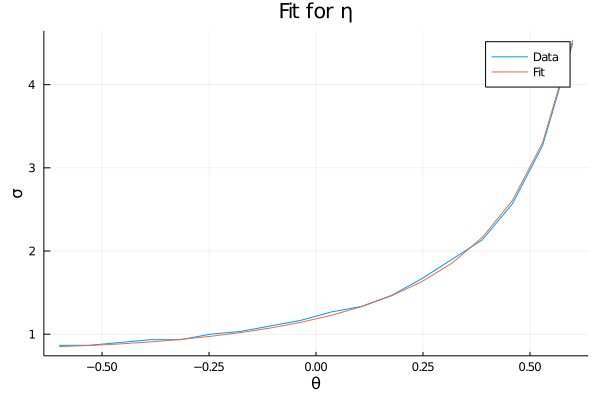

In [72]:
p1=fitter(0.95)
tdata=LinRange(-0.6,0.6,18)
data=maxfind.(tdata,0.95,tf)
f(θ)=p1*sqrt(2)/sqrt(1-sin(2*θ))
plot(tdata,[data,f],title="Fit for η",label=["Data" "Fit"],ylabel="σ",xlabel="θ")

In [ ]:
u0=[1,0]
plot(LinRange(0,1,34),fitter,title="η opt  vs k",xlabel="k",ylabel="η opt")

# Swing Equation

In [9]:
function swingsoltn(D,B,P,M,θ,u0,tspan,σ)
    g1 = LightGraphs.grid([2, 1])
    E= incidence_matrix(g1;oriented=true)
    
    function f(du,u,p,t)
        du[1:2]=u[3:4]
        du[3:4] = (-D.*u[3:4] - E*((B/2).*sin.(E'*u[1:2])) + P)./M 
    end
    
    function g(du,u,p,t)
        G=(σ/sqrt(2))*[[0,0,0,0] [0,0,0,0] [0,0,cos(θ),sin(θ)] [0,0,sin(θ),cos(θ)]]
        du.=G
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(4,4))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltn (generic function with 1 method)

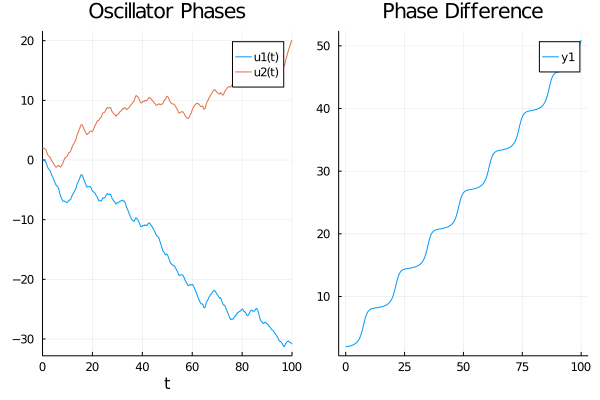

In [22]:
u0=[0,2,0,0]
M=[1,1]
D=[1,1]
B=1 #Vector of admittances
P=[-1/2,1/2]
sol1=swingsoltn(D,B,P,M,pi/4,u0,(0.0,100.0),sqrt(2))
p1=plot(sol1,title="Oscillator Phases",vars=[(0,1),(0,2)])
p2=plot([sol1.t[i] for i in 1:length(sol1[1,1:end])],abs.([sol1[1,i] for i in 1:length(sol1[1,1:end])].-[sol1[2,i] for i in 1:length(sol1[1,1:end])]),title="Phase Difference")
plot(p1,p2)

# Large Damping Small Inertia

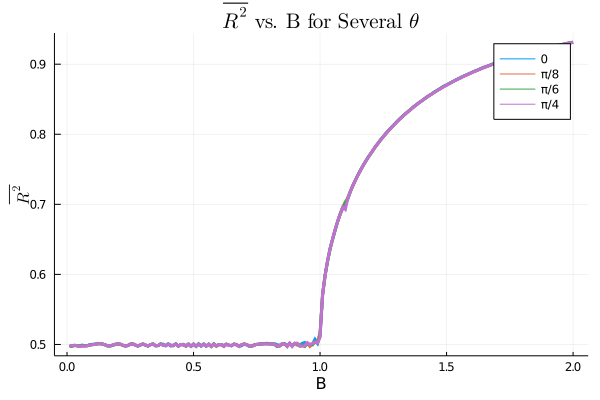

In [23]:
u0=[0,2,0,0]
D=[1,1]
M1=[0.01,0.01]
P=[-1/2,1/2]
tf=500.0
a(b)=r2(swingsoltn(D,b,P,M1,0,u0,(0.0,tf),sqrt(2)),(0.0,tf))
b(b)=r2(swingsoltn(D,b,P,M1,pi/8,u0,(0.0,tf),sqrt(2)),(0.0,tf))
c(b)=r2(swingsoltn(D,b,P,M1,pi/6,u0,(0.0,tf),sqrt(2)),(0.0,tf))
d(b)=r2(swingsoltn(D,b,P,M1,pi/4,u0,(0.0,tf),sqrt(2)),(0.0,tf))
plot(LinRange(0,2,200),[a,b,c,d],title= L"\overline{R^2} \textrm{ vs. B for Several θ}",label=["0" "π/8" "π/6" "π/4"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


# Plot b with Swing

In [ ]:
u0=[0,2,0,0]
D=[1,1]
M1=[1,1]
P=[-1/2,1/2]
tf=5000.0
a(b)=r2(swingsoltn(D,b,P,M1,-pi/4,u0,(0.0,tf),sqrt(2)),(0.0,tf))
b(b)=r2(swingsoltn(D,b,P,M1,-pi/8,u0,(0.0,tf),sqrt(2)),(0.0,tf))
c(b)=r2(swingsoltn(D,b,P,M1,0,u0,(0.0,tf),sqrt(2)),(0.0,tf))
d(b)=r2(swingsoltn(D,b,P,M1,pi/8,u0,(0.0,tf),sqrt(2)),(0.0,tf))
e(b)=r2(swingsoltn(D,b,P,M1,pi/6,u0,(0.0,tf),sqrt(2)),(0.0,tf))
f(b)=r2(swingsoltn(D,b,P,M1,pi/4,u0,(0.0,tf),sqrt(2)),(0.0,tf))
plot(LinRange(0,2,250),[a,b,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. B for Several θ}",label=["-π/4" "-π/8" "0" "π/8" "π/6" "π/4"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


# Plot C with Swing

In [ ]:
tf=5200.0
u0=[0,2,1,1]
M=[1,1]
D=[1,1]
P=[-1/2,1/2]
a(σ)=r2(swingsoltn(D,0.95,P,M,-pi/4,u0,(0.0,tf),σ),(0,tf))
b(σ)=r2(swingsoltn(D,0.95,P,M,-pi/8,u0,(0.0,tf),σ),(0,tf))
c(σ)=r2(swingsoltn(D,0.95,P,M,0,u0,(0.0,tf),σ),(0,tf))
d(σ)=r2(swingsoltn(D,0.95,P,M,pi/8,u0,(0.0,tf),σ),(0,tf))
e(σ)=r2(swingsoltn(D,0.95,P,M,pi/4,u0,(0.0,tf),σ),(0,tf))
plot(LinRange(0,8,350),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. σ for Several θ}",label=["-π/4" "-π/8" "0" "π/8" "π/4"],xlabel="σ",ylabel=L"\overline{R^2}",width=3)


# N Oscillators with 1 Covariance Parameter

In [10]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [11]:
function swingsoltnN(grid,D,B,P,M,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        du[1:n]=u[n+1:2n]
        du[n+1:2n] = (-D.*u[n+1:2n] - E*((B/n).*sin.(E'*u[1:n])) + P)./M 
    end
    
    function g(du,u,p,t)
        A=zeros(2n,2n)
        C=ρ*ones(n,n)
        C[diagind(C)] .= 1
        G=(σ/sqrt(2))*G_generate(C)
        for i in 1:n
            A[n+i,1:2n]=vcat(zeros(n),G[i,1:n])
        end
        du.=A
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(2n,2n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltnN (generic function with 1 method)

# Plot b with Swing

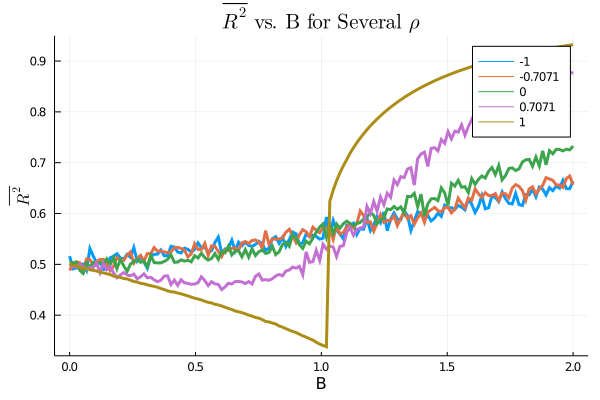

In [136]:
u0=[0,2,0,0]
D=[1,1]
M1=[1,1]
P=[-1/2,1/2]
tf=3000
g1=LightGraphs.grid([2,1])
a(b)=r2N(swingsoltnN(g1,D,b,P,M1,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
b(b)=r2N(swingsoltnN(g1,D,b,P,M1,u0,(0.0,tf),sqrt(2),-0.7071),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,b,P,M1,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,b,P,M1,u0,(0.0,tf),sqrt(2),0.7071),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,b,P,M1,u0,(0.0,tf),sqrt(2),1),(0.0,tf))
plot(LinRange(0,2,150),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. B for Several ρ}",label=["-1" "-0.7071" "0" "0.7071" "1"],xlabel="B",ylabel=L"\overline{R^2}",width=3)



In [ ]:
o,p = 2,2
g1=LightGraphs.grid([o,p])
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
B=ones(ne(g1))
u0=zeros(2*nv(g1))
sol=swingsoltnN(g1,D,B,P,M,u0,(0.0,200.0),sqrt(2),0)
varslist=[(0,i) for i in (1:nv(g1))]
plot(sol,vars=varslist,title="Oscillator Phases")

In [12]:
function r2N(sol,tspan)
    N=Int(length(sol[1:end,1])/2)
    Δt=tspan[2]-tspan[1]
    leng=length(sol[1,1:end])
    A=[exp.(sol[i,1:end].*im) for i in 1:N]
    B=zeros(leng)
    for i in 1:N
        B=B.+A[i]
    end
    return (1/Δt)*sum(abs2.((1/N)*B)*Δt/(leng-1))
end

r2N (generic function with 1 method)

# 4-Node Grid

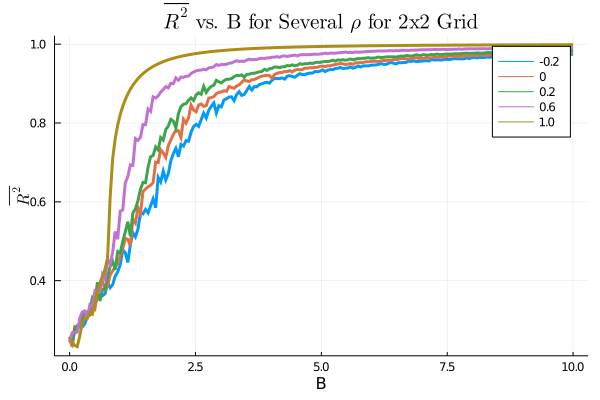

In [189]:
tf=2000.0
g1=LightGraphs.grid([2,2])
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),-0.2),(0.0,tf))
b(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.2),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.6),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,10,200),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. B for Several ρ for 2x2 Grid}",label=["-0.2" "0" "0.2" "0.6" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)

# 16-Node Grid

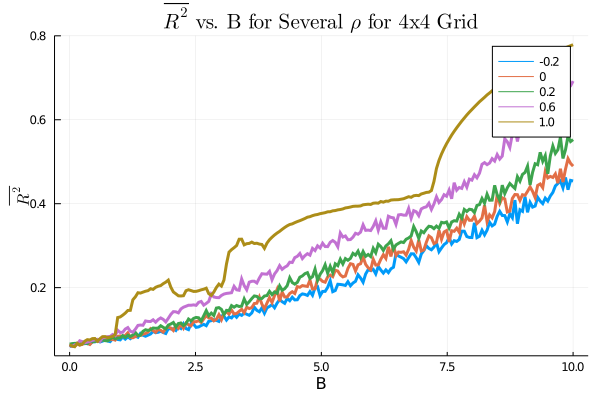

In [200]:
tf=2500.0
g1=LightGraphs.grid([4,4])
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),-0.2),(0.0,tf))
b(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.2),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.6),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,10,200),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. B for Several ρ for 4x4 Grid}",label=["-0.2" "0" "0.2" "0.6" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)

# Complete Graph with 4 Oscillators

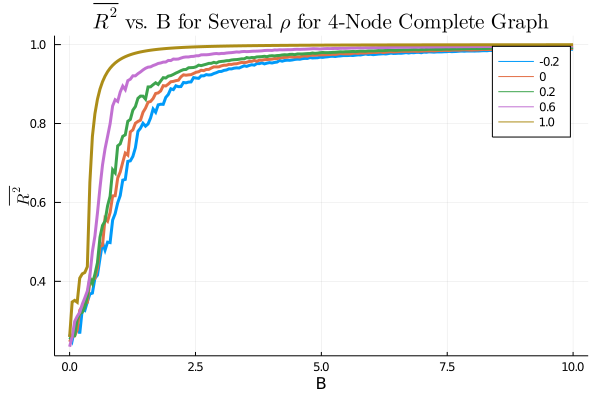

In [191]:
tf=2000.0
g1=CompleteGraph(4)
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),-0.2),(0.0,tf))
b(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.2),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.6),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,10,200),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. B for Several ρ for 4-Node Complete Graph}",label=["-0.2" "0" "0.2" "0.6" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)

# Complete Graph with 16 Oscillators

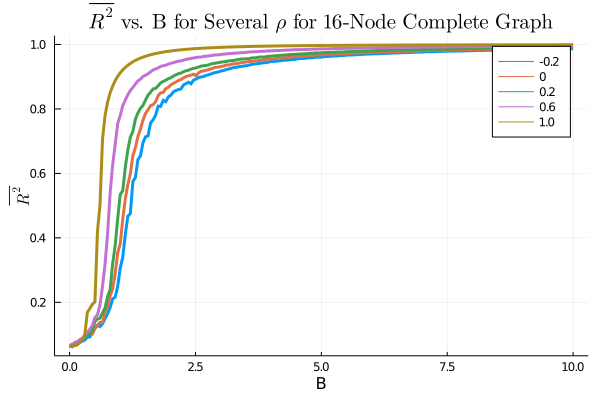

In [192]:
tf=2000.0
g1=CompleteGraph(16)
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),-0.2),(0.0,tf))
b(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
c(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.2),(0.0,tf))
d(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),0.6),(0.0,tf))
e(b)=r2N(swingsoltnN(g1,D,[b for i in 1:ne(g1)],P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,10,200),[a,b,c,d,e],title= L"\overline{R^2} \textrm{ vs. B for Several ρ for 16-Node Complete Graph}",label=["-0.2" "0" "0.2" "0.6" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)

# Synchronization on 2x2 Grid

In [13]:
function swingsoltnN3(grid,D,B,P,M,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        du[1:n]=u[n+1:2n]
        du[n+1:2n] = (-D.*u[n+1:2n] - E*((B/n).*sin.(E'*u[1:n])) + P)./M 
    end
    
    function g(du,u,p,t)
        A=zeros(2n,2n)
        C=[[1,ρ,0,0] [ρ,1,0,0] [0,0,1,ρ] [0,0,ρ,1]]
        G=(σ/sqrt(2))*G_generate(C)
        A=[zeros(8) zeros(8) zeros(8) zeros(8) vcat(zeros(4),G[1:n,1]) vcat(zeros(4),G[1:n,2]) vcat(zeros(4),G[1:n,3]) vcat(zeros(4),G[1:n,4])]
        du.=A
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(8,8))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltnN3 (generic function with 1 method)

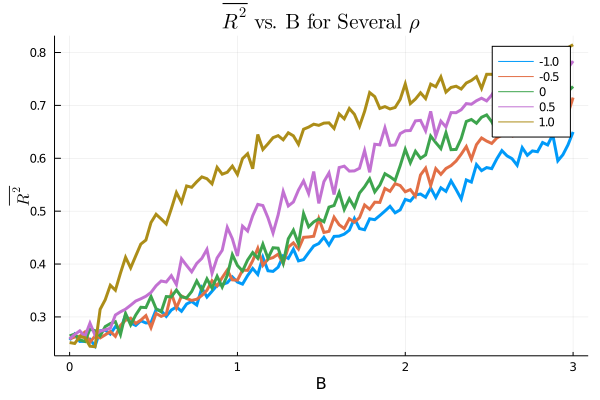

In [170]:
g1=LightGraphs.grid([2,2])
tf=2000.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
c(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
d(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
e(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
f(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,3,100),[a,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. B for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


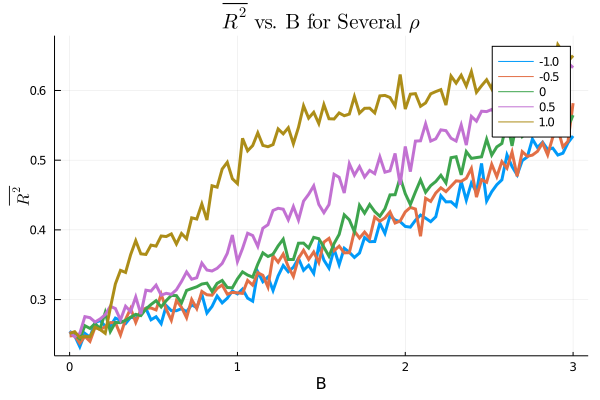

In [194]:
g1=LightGraphs.grid([2,2])
rem_edge!(g1, 2,4)
tf=2000.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
c(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
d(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
e(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
f(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,3,100),[a,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. B for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


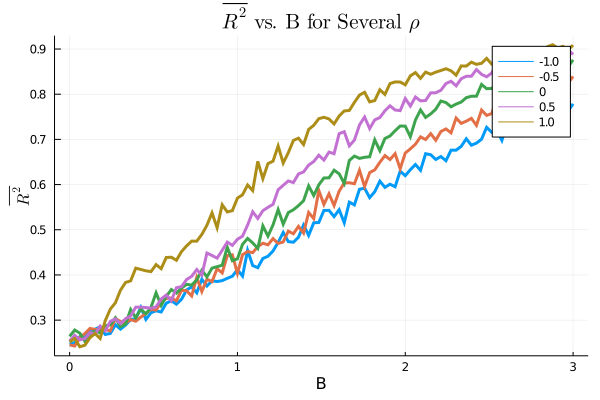

In [196]:
g1=LightGraphs.grid([2,2])
add_edge!(g1, 2,3)
add_edge!(g1,1,4)
tf=2000.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
a(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-1),(0.0,tf))
c(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),-0.5),(0.0,tf))
d(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0),(0.0,tf))
e(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),0.5),(0.0,tf))
f(b)=r2N(swingsoltnN3(g1,D,b*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),1.0),(0.0,tf))
plot(LinRange(0,3,100),[a,c,d,e,f],title= L"\overline{R^2} \textrm{ vs. B for Several ρ}",label=["-1.0" "-0.5" "0" "0.5" "1.0"],xlabel="B",ylabel=L"\overline{R^2}",width=3)


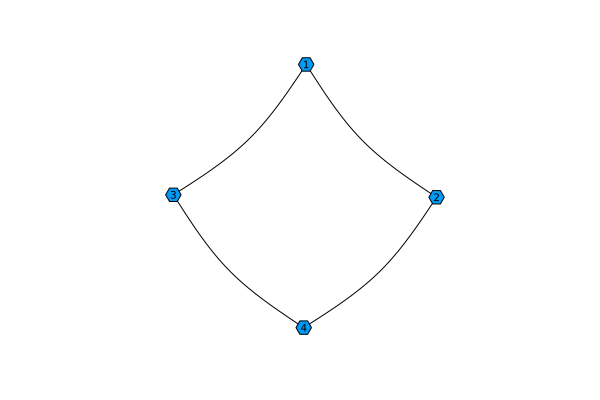

In [10]:
g1=LightGraphs.grid([2,2])
graphplot(g1,names=1:4)

In [43]:
function gmake(n)
    g1=CompleteGraph(n)
    int=Int(nv(g1)/2)
    for i in 1:int
        for j in (int+1):Int(2*int)
            rem_edge!(g1,i,j)
        end
    add_edge!(g1,i,int+i)
    end
    return g1
end

gmake (generic function with 1 method)

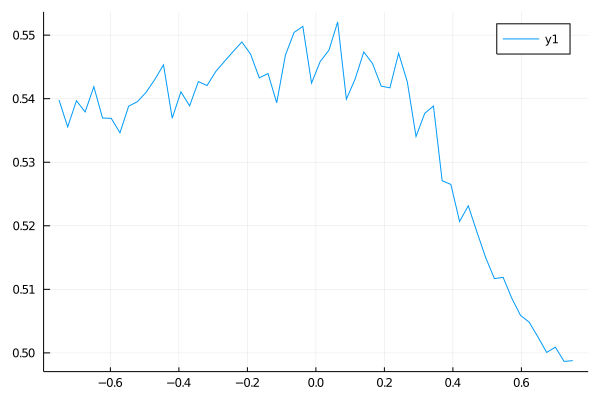

In [68]:
tf=10000.0
a(θ)=r2(soltn(0.4,θ,[0,0],tf,sqrt(2)),(0,tf))
plot(LinRange(-3/4,3/4,60),a)